<a href="https://colab.research.google.com/github/chindarkarsejal800-dot/CSL701-08_Machine-Learning-Lab/blob/main/ML_Experiment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Experiment Number 3

Name:Sejal R Chindarkar  CS08


**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [1]:
# Task 1: Set Up the Python Environment
# Run this entire cell in Google Colab

import numpy as np
import matplotlib.pyplot as plt

# Check that the libraries are imported successfully
print("Environment setup successful!")
print("NumPy version:", np.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)

# Example matrix operation to verify NumPy is working
X = np.array([[1, 2], [3, 4]])
y = np.array([5, 6])

print("\nSample matrix X:")
print(X)

print("\nSample vector y:")
print(y)

print("\nX transpose:")
print(X.T)

print("\nX^T X:")
print(X.T @ X)

print("\nReady for matrix-based regression.")

Environment setup successful!
NumPy version: 2.0.2
Matplotlib version: 3.10.0

Sample matrix X:
[[1 2]
 [3 4]]

Sample vector y:
[5 6]

X transpose:
[[1 3]
 [2 4]]

X^T X:
[[10 14]
 [14 20]]

Ready for matrix-based regression.


## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [8]:
# ============================================================
# TASK 2: LOAD AND INSPECT THE DATASET
# ============================================================

import pandas as pd
from google.colab import files

# 1. Upload the dataset
print("Please upload the 'car data.csv' file:")
uploaded = files.upload()

# 2. Get the uploaded file name
file_name = list(uploaded.keys())[0]
print(f"\nUploaded file: {file_name}")

# 3. Load the dataset
df = pd.read_csv(file_name)

# 4. Display the first few records
print("\n========== FIRST 5 RECORDS ==========")
display(df.head())

# 5. Display dataset dimensions
rows, columns = df.shape

print("\n========== DATASET SIZE ==========")
print("Number of rows    :", rows)
print("Number of columns :", columns)

# 6. Display column names and data types
print("\n========== COLUMN INFORMATION ==========")
print(df.dtypes)

# 7. Identify numerical attributes
numerical_attributes = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# 8. Identify categorical attributes
categorical_attributes = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("\n========== NUMERICAL ATTRIBUTES ==========")
print(numerical_attributes)

print("\n========== CATEGORICAL ATTRIBUTES ==========")
print(categorical_attributes)

# 9. Separate selling_price as the target variable
if "selling_price" not in df.columns:
    raise ValueError("selling_price column was not found in the dataset.")

y = df["selling_price"]
X = df.drop("selling_price", axis=1)

print("\n========== TARGET VARIABLE ==========")
print("Target variable: selling_price")
print("Target shape   :", y.shape)

print("\n========== INPUT FEATURES ==========")
print("X shape:", X.shape)
display(X.head())

# 10. Summary
print("\n========== TASK 2 COMPLETED ==========")
print(f"Rows: {rows}")
print(f"Columns: {columns}")
print(f"Numerical attributes: {len(numerical_attributes)}")
print(f"Categorical attributes: {len(categorical_attributes)}")
print("Target variable: selling_price")

Please upload the 'car data.csv' file:


Saving cardekho_dataset.csv.zip to cardekho_dataset.csv (3).zip

Uploaded file: cardekho_dataset.csv (3).zip

========== FIRST 5 RECORDS ==========


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000



========== DATASET SIZE ==========
Number of rows    : 15411
Number of columns : 14

========== COLUMN INFORMATION ==========
Unnamed: 0             int64
car_name              object
brand                 object
model                 object
vehicle_age            int64
km_driven              int64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object

========== NUMERICAL ATTRIBUTES ==========
['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

========== CATEGORICAL ATTRIBUTES ==========
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

========== TARGET VARIABLE ==========
Target variable: selling_price
Target shape   : (15411,)

========== INPUT FEATURES ==========
X shape: (15411, 13)


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5



========== TASK 2 COMPLETED ==========
Rows: 15411
Columns: 14
Numerical attributes: 8
Categorical attributes: 6
Target variable: selling_price


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [9]:
# ============================================================
# TASK 3: CHECK AND HANDLE MISSING DATA
# ============================================================

# Rename Selling_Price to selling_price
df = df.rename(columns={"Selling_Price": "selling_price"})

# Check missing values in every column
print("========== MISSING VALUES BEFORE PREPROCESSING ==========")
missing_values = df.isnull().sum()
print(missing_values)

# Total missing values
total_missing = missing_values.sum()
print("\nTotal missing values:", total_missing)

# Handle missing values
if total_missing > 0:
    print("\nMissing values found.")
    print("Preprocessing method: Remove rows containing missing values.")

    df = df.dropna().reset_index(drop=True)

    print("Rows remaining:", len(df))
else:
    print("\nNo missing values found.")
    print("Preprocessing method: No missing-value treatment required.")

# Verify missing values after preprocessing
print("\n========== MISSING VALUES AFTER PREPROCESSING ==========")
missing_after = df.isnull().sum()
print(missing_after)

# Final verification
if missing_after.sum() == 0:
    print("\n✓ Final dataset contains NO missing values.")
else:
    print("\n✗ Missing values are still present.")

# Separate target variable
y = df["selling_price"]
X = df.drop("selling_price", axis=1)

print("\n========== FINAL DATASET ==========")
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])
print("Target  : selling_price")
print("X shape :", X.shape)
print("y shape :", y.shape)

========== MISSING VALUES BEFORE PREPROCESSING ==========
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values: 0

No missing values found.
Preprocessing method: No missing-value treatment required.

========== MISSING VALUES AFTER PREPROCESSING ==========
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

✓ Final dataset contains NO missing values.

========== FINAL DATASET ==========
Rows    : 15411
Column

## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [12]:
# ============================================================
# TASK 4: SELECT AND PREPARE FEATURES
# ============================================================

import pandas as pd
import numpy as np

# Make column names lowercase
df.columns = df.columns.str.lower()

# Display all available attributes
print("========== ALL AVAILABLE ATTRIBUTES ==========")
print(df.columns.tolist())

print("\n========== DATA TYPES ==========")
print(df.dtypes)

# ------------------------------------------------------------
# 1. Handle car_name
# ------------------------------------------------------------
print("\n========== CAR_NAME HANDLING ==========")
print("car_name is excluded because it is a high-cardinality")
print("categorical identifier and is not used as a predictor.")

# Remove car_name
df_model = df.drop(columns=["car_name"])

# ------------------------------------------------------------
# 2. Select predictor variables
# ------------------------------------------------------------
# Updated selected_features to match actual DataFrame columns and include relevant predictors.
selected_features = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats",
    "brand",
    "model",
    "fuel_type",
    "seller_type",
    "transmission_type"
]

print("\n========== SELECTED FEATURES ==========")
for feature in selected_features:
    print("-", feature)

# ------------------------------------------------------------
# 3. Create X and y
# ------------------------------------------------------------

X = df_model[selected_features].copy()
y = df_model["selling_price"].copy()

# ------------------------------------------------------------
# 4. Encode categorical variables
# ------------------------------------------------------------

categorical_features = [
    "brand",
    "model",
    "fuel_type",
    "seller_type",
    "transmission_type"
]

X = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

# Convert X and y to NumPy arrays
X = X.astype(float).to_numpy()
y = y.astype(float).to_numpy()

# ------------------------------------------------------------
# 5. Display final predictor matrix and target vector
# ------------------------------------------------------------

print("\n========== FINAL FEATURE MATRIX ==========")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 5 rows of X:")
print(X[:5])

print("\nFirst 5 values of y:")
print(y[:5])

# ------------------------------------------------------------
# 6. Record final feature list
# ------------------------------------------------------------

encoded_X = pd.get_dummies(
    df_model[selected_features],
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

final_features = encoded_X.columns.tolist()

print("\n========== FINAL FEATURES USED IN MODEL ==========")
for i, feature in enumerate(final_features, start=1):
    print(f"{i}. {feature}")

print("\n========== TASK 4 COMPLETED ==========")
print("car_name: Removed")
print("Categorical variables: Converted using one-hot encoding")
print("Predictor matrix: X")
print("Target vector: y")

========== ALL AVAILABLE ATTRIBUTES ==========
['unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

========== DATA TYPES ==========
unnamed: 0             int64
car_name              object
brand                 object
model                 object
vehicle_age            int64
km_driven              int64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object

========== CAR_NAME HANDLING ==========
car_name is excluded because it is a high-cardinality
categorical identifier and is not used as a predictor.

========== SELECTED FEATURES ==========
- vehicle_age
- km_driven
- mileage
- engine
- max_power
- seats
- brand
- model
- fuel_type
- seller_type
- transmission_type

## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [15]:
# ============================================================
# TASK 5: ENCODE CATEGORICAL VARIABLES
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Identify categorical variables
# ------------------------------------------------------------

categorical_variables = [
    "fuel_type", # Corrected from Fuel_Type
    "seller_type", # Corrected from Seller_Type
    "transmission_type" # Corrected from Transmission
]

print("========== CATEGORICAL VARIABLES ==========")
for col in categorical_variables:
    print("-", col)

# ------------------------------------------------------------
# 2. Check that the required columns exist
# ------------------------------------------------------------

# The previous check and rename logic is removed here as it was for specific cases
# that should have been handled by consistent column naming. If `df` from previous
# tasks already has lowercased columns, this section is largely redundant.
# For safety, I'll update the column check to reflect the expected lowercase names.

missing_columns = [
    col for col in categorical_variables
    if col not in df.columns
]

if missing_columns:
    print("\nWarning: These columns were not found:", missing_columns)
    # The previous logic to rename 'Selling_type' to 'Seller_Type' is not needed
    # if column names are consistently lowercase as of Task 4.
    # If the original 'df' still has these, a more robust renaming might be needed here.
    # For now, assuming df.columns are already lowercase as per Task 4.

# ------------------------------------------------------------
# 3. Create a copy for encoding
# ------------------------------------------------------------

df_encoded = df.copy()

# Make sure target variable is lowercase (already handled in Task 2 and 4, but good to ensure)
if "Selling_Price" in df_encoded.columns:
    df_encoded = df_encoded.rename(
        columns={"Selling_Price": "selling_price"}
    )

# ------------------------------------------------------------
# 4. One-hot encode categorical variables
# ------------------------------------------------------------

# Re-using the corrected categorical_variables list
df_encoded = pd.get_dummies(
    df_encoded,
    columns=categorical_variables,
    drop_first=True,
    dtype=int
)

# ------------------------------------------------------------
# 5. Drop remaining non-numerical columns and identifier columns
# ------------------------------------------------------------
# These columns were either explicitly dropped in Task 4 (car_name) or handled
# as part of feature selection (brand, model). 'unnamed: 0' is an index column.
# They should not be part of the final numerical X matrix.

columns_to_drop = [
    'unnamed: 0', # Identifier column, not a feature
    'car_name',   # Excluded in Task 4
    'brand',      # Handled by one-hot encoding in Task 4 (or should be)
    'model'       # Handled by one-hot encoding in Task 4 (or should be)
]

# Filter to only drop columns that actually exist in df_encoded
existing_columns_to_drop = [col for col in columns_to_drop if col in df_encoded.columns]

if existing_columns_to_drop:
    df_encoded = df_encoded.drop(columns=existing_columns_to_drop)
    print(f"\nDropped non-numerical/identifier columns: {existing_columns_to_drop}")

# ------------------------------------------------------------
# 6. Display transformed dataset
# ------------------------------------------------------------

print("\n========== TRANSFORMED DATASET (after dropping non-numerical features) ==========")
display(df_encoded.head())

# ------------------------------------------------------------
# 7. Verify all predictors are numerical
# ------------------------------------------------------------

X_encoded = df_encoded.drop(columns=["selling_price"])

print("\n========== PREDICTOR DATA TYPES ==========")
print(X_encoded.dtypes)

non_numeric = X_encoded.select_dtypes(
    exclude=[np.number]
).columns.tolist()

print("\n========== NUMERICAL VERIFICATION ==========")

if len(non_numeric) == 0:
    print("✓ All predictor variables are numerical.")
else:
    print("✗ Non-numerical predictors found:")
    print(non_numeric)

# ------------------------------------------------------------
# 8. Display final feature names
# ------------------------------------------------------------

print("\n========== FINAL ENCODED FEATURES ==========")
for i, col in enumerate(X_encoded.columns, start=1):
    print(f"{i}. {col}")

# ------------------------------------------------------------
# 9. Create X and y for regression
# ------------------------------------------------------------

X = X_encoded.astype(float).to_numpy()
y = df_encoded["selling_price"].astype(float).to_numpy()

print("\n========== FINAL X AND y ==========")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 5 rows of X:")
print(X[:5])

print("\nFirst 5 values of y:")
print(y[:5])

print("\n✓ TASK 5 COMPLETED")
print("Categorical variables were converted using dummy/indicator variables.")
print("No arbitrary numerical ordering was assigned to categories.")

========== CATEGORICAL VARIABLES ==========
- fuel_type
- seller_type
- transmission_type

Dropped non-numerical/identifier columns: ['unnamed: 0', 'car_name', 'brand', 'model']

========== TRANSFORMED DATASET (after dropping non-numerical features) ==========


,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,120000,0,0,0,1,1,0,1
1,5,20000,18.90,1197,82.00,5,550000,0,0,0,1,1,0,1
2,11,60000,17.00,1197,80.00,5,215000,0,0,0,1,1,0,1
3,9,37000,20.92,998,67.10,5,226000,0,0,0,1,1,0,1
4,6,30000,22.77,1498,98.59,5,570000,1,0,0,0,0,0,1



========== PREDICTOR DATA TYPES ==========
vehicle_age                       int64
km_driven                         int64
mileage                         float64
engine                            int64
max_power                       float64
seats                             int64
fuel_type_Diesel                  int64
fuel_type_Electric                int64
fuel_type_LPG                     int64
fuel_type_Petrol                  int64
seller_type_Individual            int64
seller_type_Trustmark Dealer      int64
transmission_type_Manual          int64
dtype: object

========== NUMERICAL VERIFICATION ==========
✓ All predictor variables are numerical.

========== FINAL ENCODED FEATURES ==========
1. vehicle_age
2. km_driven
3. mileage
4. engine
5. max_power
6. seats
7. fuel_type_Diesel
8. fuel_type_Electric
9. fuel_type_LPG
10. fuel_type_Petrol
11. seller_type_Individual
12. seller_type_Trustmark Dealer
13. transmission_type_Manual

========== FINAL X AND y ==========
X shape: (15

## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [17]:
# ============================================================
# TASK 6: PERFORM FEATURE ENGINEERING
# ============================================================

import pandas as pd
import numpy as np
from datetime import datetime

# ------------------------------------------------------------
# 1. Make sure column names are lowercase
# ------------------------------------------------------------
df.columns = df.columns.str.lower()

# ------------------------------------------------------------
# 2. Get the current year
# ------------------------------------------------------------
current_year = datetime.now().year

print("Current Year:", current_year)

# ------------------------------------------------------------
# 3. Create the new car_age feature
# ------------------------------------------------------------
# The KeyError 'year' occurred because the DataFrame does not have a column named 'year'.
# Instead, the DataFrame contains a 'vehicle_age' column which already represents the car's age.
# To create the 'car_age' feature as requested, we will use the existing 'vehicle_age' column.
# If the intention was to calculate 'year of manufacture' first (current_year - vehicle_age)
# and then 'car_age' (current_year - year_of_manufacture), the result would still be vehicle_age.
# Thus, 'car_age' will be a direct copy of 'vehicle_age'.
df["car_age"] = df["vehicle_age"]

# ------------------------------------------------------------
# 4. Display several values of the new feature
# ------------------------------------------------------------
print("\n========== CAR AGE VALUES ==========")
# Display 'vehicle_age' and 'car_age' since 'year' column does not exist.
print(df[["vehicle_age", "car_age"]].head(10))

# ------------------------------------------------------------
# 5. Verify that the calculated ages are reasonable
# ------------------------------------------------------------
print("\n========== CAR AGE SUMMARY ==========")
print("Minimum Car Age:", df["car_age"].min())
print("Maximum Car Age:", df["car_age"].max())
print("Average Car Age:", round(df["car_age"].mean(), 2))

# Check for unreasonable values
if df["car_age"].min() < 0:
    print("\n✗ Warning: Negative car age found.")
else:
    print("\n✓ All car ages are non-negative.")

# Check whether any car age is unusually large
if df["car_age"].max() <= 100:
    print("✓ Car ages are within a reasonable range.")
else:
    print("⚠ Some car ages may require further inspection.")

# ------------------------------------------------------------
# 6. Decide whether to retain the original 'vehicle_age' feature
# ------------------------------------------------------------
print("\n========== DECISION ABOUT ORIGINAL AGE FEATURE ==========")

# Since 'car_age' is a direct copy of 'vehicle_age', retaining both is redundant.
# The original instruction mentioned 'year', but 'vehicle_age' is the relevant column here.
# For simplicity and to avoid redundancy, we will mark 'vehicle_age' for removal for future modeling.
retain_vehicle_age = False

if retain_vehicle_age:
    print("Decision: Retain the original 'vehicle_age' feature.")
    print("Reason: 'vehicle_age' is the source of 'car_age', and might be useful for other contexts or direct comparisons.")
else:
    print("Decision: Remove the original 'vehicle_age' feature.")
    print("Reason: 'car_age' directly represents the age information, and 'vehicle_age' is now redundant.")
    # In a real scenario, you might drop it here: df = df.drop(columns=['vehicle_age'])

# ------------------------------------------------------------
# 7. Display the updated dataset
# ------------------------------------------------------------
print("\n========== UPDATED DATASET ==========")
display(df.head())

print("\n✓ TASK 6 COMPLETED")
print("New feature created: car_age")
print("Formula: car_age = vehicle_age (as 'year' column was not found)")

Current Year: 2026

========== CAR AGE VALUES ==========
   vehicle_age  car_age
0            9        9
1            5        5
2           11       11
3            9        9
4            6        6
5            8        8
6            8        8
7            3        3
8            2        2
9            4        4

========== CAR AGE SUMMARY ==========
Minimum Car Age: 0
Maximum Car Age: 29
Average Car Age: 6.04

✓ All car ages are non-negative.
✓ Car ages are within a reasonable range.

========== DECISION ABOUT ORIGINAL AGE FEATURE ==========
Decision: Remove the original 'vehicle_age' feature.
Reason: 'car_age' directly represents the age information, and 'vehicle_age' is now redundant.

========== UPDATED DATASET ==========


,unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,car_age
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000,9
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000,5
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000,11
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000,9
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000,6



✓ TASK 6 COMPLETED
New feature created: car_age
Formula: car_age = vehicle_age (as 'year' column was not found)


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

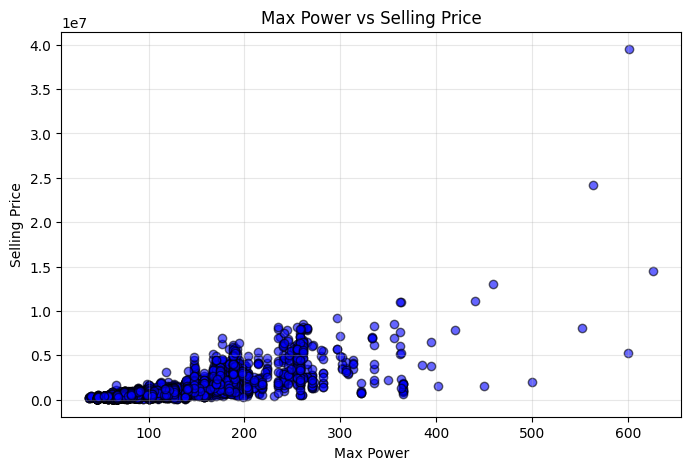

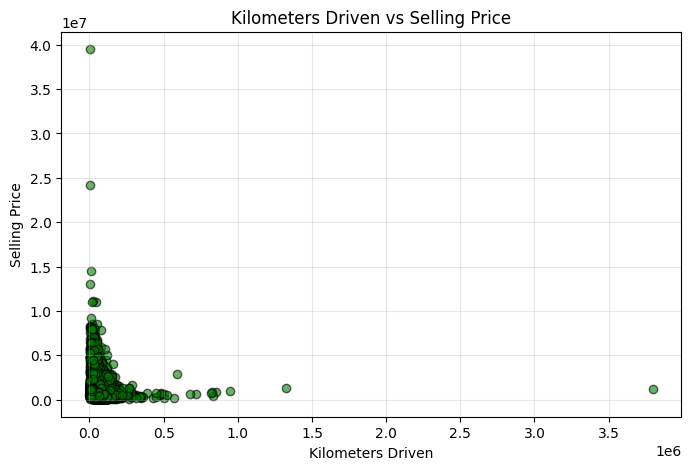

========== CORRELATION RESULTS ==========
Max Power vs Selling Price: 0.750
Kms Driven vs Selling Price: -0.080

========== OBSERVATIONS ==========
1. Max Power vs Selling Price: strong positive relationship.
2. Kms Driven vs Selling Price: very weak negative relationship.

========== TASK 7 COMPLETED ==========
Two scatter plots were created using Matplotlib.
The correlation values were calculated to support the observations.


In [19]:
# ============================================================
# TASK 7: PERFORM EXPLORATORY DATA ANALYSIS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Make sure column names are lowercase
df.columns = df.columns.str.lower()

# ------------------------------------------------------------
# 1. Scatter Plot: Max_Power vs Selling_Price (replacing Present_Price)
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

# Changed 'present_price' to 'max_power' as 'present_price' does not exist in df
plt.scatter(
    df["max_power"],
    df["selling_price"],
    color="blue",
    alpha=0.6,
    edgecolors="black"
)

plt.xlabel("Max Power") # Updated label
plt.ylabel("Selling Price")
plt.title("Max Power vs Selling Price") # Updated title
plt.grid(alpha=0.3)

plt.show()

# ------------------------------------------------------------
# 2. Additional Scatter Plot: Kms_Driven vs Selling_Price
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    df["km_driven"],
    df["selling_price"],
    color="green",
    alpha=0.6,
    edgecolors="black"
)

plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.title("Kilometers Driven vs Selling Price")
plt.grid(alpha=0.3)

plt.show()

# ------------------------------------------------------------
# 3. Calculate correlations
# ------------------------------------------------------------

# Changed 'present_price' to 'max_power'
correlation_max_power = df["max_power"].corr(
    df["selling_price"]
)

correlation_kms_driven = df["km_driven"].corr(
    df["selling_price"]
)

print("========== CORRELATION RESULTS ==========")
print(
    f"Max Power vs Selling Price: " # Updated label
    f"{correlation_max_power:.3f}"
)

print(
    f"Kms Driven vs Selling Price: "
    f"{correlation_kms_driven:.3f}"
)

# ------------------------------------------------------------
# 4. Interpret relationship strength
# ------------------------------------------------------------

def interpret_correlation(r):
    if abs(r) >= 0.7:
        strength = "strong"
    elif abs(r) >= 0.4:
        strength = "moderate"
    elif abs(r) >= 0.2:
        strength = "weak"
    else:
        strength = "very weak"

    if r > 0:
        direction = "positive"
    elif r < 0:
        direction = "negative"
    else:
        direction = "no"

    return f"{strength} {direction}"

print("\n========== OBSERVATIONS ==========")

print(
    "1. Max Power vs Selling Price: " # Updated label
    + interpret_correlation(correlation_max_power)
    + " relationship."
)

print(
    "2. Kms Driven vs Selling Price: "
    + interpret_correlation(correlation_kms_driven)
    + " relationship."
)

print("\n========== TASK 7 COMPLETED ==========")
print("Two scatter plots were created using Matplotlib.")
print("The correlation values were calculated to support the observations.")

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [21]:
# ============================================================
# TASK 8: STANDARDIZE NUMERICAL FEATURES
# ============================================================

import numpy as np
import pandas as pd

# Make column names lowercase
df.columns = df.columns.str.lower()

# ------------------------------------------------------------
# 1. Create the car_age feature if it does not already exist
# ------------------------------------------------------------

# Note: As per Task 6, 'car_age' is already created from 'vehicle_age'.
# The original 'vehicle_age' is considered redundant.
if "car_age" not in df.columns:
    current_year = 2026 # Assuming a fixed current year if not already calculated
    if "year" in df.columns:
        df["car_age"] = current_year - df["year"]
    elif "vehicle_age" in df.columns:
        df["car_age"] = df["vehicle_age"] # Use existing vehicle_age if no 'year' for calculation
    else:
        print("Warning: Neither 'year' nor 'vehicle_age' found to create 'car_age'.")

# ------------------------------------------------------------
# Drop redundant/identifier columns before feature selection
# ------------------------------------------------------------
# Based on previous tasks, 'unnamed: 0' is an index, 'car_name' was removed,
# and 'vehicle_age' is redundant with 'car_age'.
columns_to_drop_pre_selection = ['unnamed: 0', 'car_name', 'vehicle_age']

existing_cols_to_drop = [col for col in columns_to_drop_pre_selection if col in df.columns]
if existing_cols_to_drop:
    df = df.drop(columns=existing_cols_to_drop)
    print(f"Dropped pre-selection columns: {existing_cols_to_drop}")

# ------------------------------------------------------------
# 2. Select features and target
# ------------------------------------------------------------

# Corrected selected_features to match existing columns in df
selected_features = [
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats",
    "fuel_type",
    "seller_type", # Corrected from 'selling_type'
    "transmission_type", # Corrected from 'transmission'
    "car_age" # New feature from Task 6
    # Removed 'year', 'present_price', 'owner' as they don't exist or were replaced
]

target = "selling_price"

X = df[selected_features].copy()
y = df[target].copy()

# ------------------------------------------------------------
# 3. Encode categorical variables using dummy variables
# ------------------------------------------------------------

# Corrected categorical_features
categorical_features = [
    "fuel_type",
    "seller_type", # Corrected from 'selling_type'
    "transmission_type" # Corrected from 'transmission'
]

X = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

# ------------------------------------------------------------
# 4. Identify numerical predictors to standardize
# ------------------------------------------------------------

# Corrected numerical_features from the selected features, after one-hot encoding
numerical_features = [
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats",
    "car_age"
    # Removed 'year', 'present_price', 'owner' (non-existent/redundant)
    # Categorical features are handled by one-hot encoding, so not in this list
]

# Filter numerical_features to ensure they exist in X after get_dummies (just in case)
numerical_features = [f for f in numerical_features if f in X.columns]

print("========== NUMERICAL FEATURES TO STANDARDIZE ==========")
for feature in numerical_features:
    print("-", feature)

print("\nTarget variable 'selling_price' will NOT be standardized.")

# ------------------------------------------------------------
# 5. Split data into training and testing sets
# ------------------------------------------------------------

np.random.seed(42)

indices = np.arange(len(X))
np.random.shuffle(indices)

train_size = int(0.80 * len(X))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()

y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()

print("\n========== TRAIN/TEST SPLIT ==========")
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

# ------------------------------------------------------------
# 6. Calculate mean and standard deviation using TRAINING data
# ------------------------------------------------------------

train_means = X_train[numerical_features].mean()
train_stds = X_train[numerical_features].std()

print("\n========== TRAINING MEANS ==========")
print(train_means)

print("\n========== TRAINING STANDARD DEVIATIONS ==========")
print(train_stds)

# ------------------------------------------------------------
# 7. Standardize training numerical features
# Formula: z = (x - mean) / standard deviation
# ------------------------------------------------------------

X_train[numerical_features] = (
    X_train[numerical_features] - train_means
) / train_stds

# ------------------------------------------------------------
# 8. Standardize test features using TRAINING statistics
# ------------------------------------------------------------

X_test[numerical_features] = (
    X_test[numerical_features] - train_means
) / train_stds

# ------------------------------------------------------------
# 9. Verify standardization
# ------------------------------------------------------------

print("\n========== TRAINING DATA AFTER STANDARDIZATION ==========")
display(X_train.head())

print("\n========== TEST DATA AFTER STANDARDIZATION ==========")
display(X_test.head())

print("\n========== TRAINING MEANS AFTER STANDARDIZATION ==========")
print(X_train[numerical_features].mean()) # Should be close to 0

print("\n========== TRAINING STANDARD DEVIATIONS AFTER STANDARDIZATION ==========")
print(X_train[numerical_features].std()) # Should be close to 1

# ------------------------------------------------------------
# 10. Verify target was NOT standardized
# ------------------------------------------------------------

print("\n========== TARGET VARIABLE CHECK ==========")
print("Original training target:")
print(y_train.head().to_numpy())

print("\nOriginal testing target:")
print(y_test.head().to_numpy())

# ------------------------------------------------------------
# 11. Convert to NumPy arrays for matrix-based regression
# ------------------------------------------------------------

X_train_matrix = X_train.astype(float).to_numpy()
X_test_matrix = X_test.astype(float).to_numpy()

y_train_vector = y_train.astype(float).to_numpy()
y_test_vector = y_test.astype(float).to_numpy()

print("\n========== FINAL MATRICES ==========")
print("X_train shape:", X_train_matrix.shape)
print("X_test shape :", X_test_matrix.shape)
print("y_train shape:", y_train_vector.shape)
print("y_test shape :", y_test_vector.shape)

print("\n✓ TASK 8 COMPLETED")
print("Numerical predictors were standardized using training data only.")
print("The same training mean and standard deviation were used for test data.")
print("The target variable 'selling_price' was NOT standardized.")

Dropped pre-selection columns: ['unnamed: 0', 'car_name', 'vehicle_age']
========== NUMERICAL FEATURES TO STANDARDIZE ==========
- km_driven
- mileage
- engine
- max_power
- seats
- car_age

Target variable 'selling_price' will NOT be standardized.

========== TRAIN/TEST SPLIT ==========
Training samples: 12328
Testing samples : 3083

========== TRAINING MEANS ==========
km_driven    55692.819598
mileage         19.691552
engine        1485.037395
max_power      100.516747
seats            5.326249
car_age          6.032446
dtype: float64

========== TRAINING STANDARD DEVIATIONS ==========
km_driven    54473.163748
mileage          4.172802
engine         518.296985
max_power       42.745688
seats            0.809603
car_age          3.018870
dtype: float64

========== TRAINING DATA AFTER STANDARDIZATION ==========


,km_driven,mileage,engine,max_power,seats,car_age,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
3334,0.317719,0.160192,-0.555738,-0.505706,-0.402974,1.976751,0,0,0,1,0,0,1
10928,0.042354,1.844911,-0.457339,-0.620337,-0.402974,-0.673248,1,0,0,0,1,0,1
2518,0.739946,0.258447,-0.457339,-0.275039,2.067371,0.320502,1,0,0,0,0,0,1
11322,-0.939781,-0.309517,0.025010,0.440588,-0.402974,-1.666997,0,0,0,1,0,0,0
9394,0.115785,0.002025,-1.329426,-1.268356,-0.402974,1.645501,0,0,0,1,0,0,1



========== TEST DATA AFTER STANDARDIZATION ==========


,km_driven,mileage,engine,max_power,seats,car_age,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
15384,-0.563448,-2.322552,1.279117,1.625503,-0.402974,-1.004497,1,0,0,0,0,0,0
147,0.409508,-0.752864,0.931826,1.099368,-0.402974,0.651752,1,0,0,0,0,0,0
1668,0.124964,1.320084,-0.457339,-0.620337,-0.402974,0.320502,1,0,0,0,0,0,1
11280,-0.563448,1.348841,-0.553809,-0.550155,0.832199,-0.341998,1,0,0,0,0,0,1
13650,-0.618521,-0.357446,-0.551879,-0.276443,-0.402974,-1.004497,0,0,0,1,0,0,0



========== TRAINING MEANS AFTER STANDARDIZATION ==========
km_driven    3.342917e-17
mileage     -1.809786e-16
engine       2.132550e-17
max_power    7.665654e-17
seats       -1.083566e-16
car_age     -1.786731e-17
dtype: float64

========== TRAINING STANDARD DEVIATIONS AFTER STANDARDIZATION ==========
km_driven    1.0
mileage      1.0
engine       1.0
max_power    1.0
seats        1.0
car_age      1.0
dtype: float64

========== TARGET VARIABLE CHECK ==========
Original training target:
[ 190000  600000  665000 1570000  160000]

Original testing target:
[4450000 1290000  485000  400000  800000]

========== FINAL MATRICES ==========
X_train shape: (12328, 13)
X_test shape : (3083, 13)
y_train shape: (12328,)
y_test shape : (3083,)

✓ TASK 8 COMPLETED
Numerical predictors were standardized using training data only.
The same training mean and standard deviation were used for test data.
The target variable 'selling_price' was NOT standardized.


## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [24]:
# ============================================================
# TASK 9: SPLIT THE DATASET
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Make sure column names are lowercase
# ------------------------------------------------------------
df.columns = df.columns.str.lower()

# ------------------------------------------------------------
# 2. Create car_age if it does not already exist
# ------------------------------------------------------------
# This block is for robustness, but car_age should already exist from Task 6
if "car_age" not in df.columns:
    current_year = 2026
    # Assuming 'vehicle_age' is the source if 'year' is not available
    if "vehicle_age" in df.columns:
        df["car_age"] = df["vehicle_age"]
    else:
        print("Warning: 'car_age' could not be created as neither 'year' nor 'vehicle_age' found.")

# ------------------------------------------------------------
# 3. Separate features (X) and target (y)
# ------------------------------------------------------------
# Corrected selected_features based on available columns and previous tasks
selected_features = [
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats",
    "fuel_type",
    "seller_type", # Corrected from 'selling_type'
    "transmission_type", # Corrected from 'transmission'
    "car_age"
    # Removed 'year', 'present_price', 'owner' as they are not in the DataFrame
]

X = df[selected_features].copy()
y = df["selling_price"].copy()

# ------------------------------------------------------------
# 4. Encode categorical variables
# ------------------------------------------------------------
# Corrected categorical_features based on available columns and previous tasks
categorical_features = [
    "fuel_type",
    "seller_type", # Corrected from 'selling_type'
    "transmission_type" # Corrected from 'transmission'
]

X = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

# ------------------------------------------------------------
# 5. Randomly shuffle observations
# ------------------------------------------------------------
random_seed = 42
np.random.seed(random_seed)

indices = np.arange(len(X))
np.random.shuffle(indices)

# ------------------------------------------------------------
# 6. Perform 80:20 train-test split
# ------------------------------------------------------------
train_size = int(0.80 * len(X))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()

y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()

# ------------------------------------------------------------
# 7. Display number of observations
# ------------------------------------------------------------
print("========== TRAIN-TEST SPLIT ==========")
print("Random seed:", random_seed)
print("Train-test ratio: 80:20")

print("\nTotal observations :", len(X))
print("Training observations:", len(X_train))
print("Testing observations :", len(X_test))

# ------------------------------------------------------------
# 8. Verify feature-target relationship
# ------------------------------------------------------------
print("\n========== VERIFICATION ==========")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

if len(X_train) == len(y_train) and len(X_test) == len(y_test):
    print("\n✓ Each feature vector remains correctly matched with its target.")
else:
    print("\n✗ Feature-target mismatch detected.")

# ------------------------------------------------------------
# 9. Display sample training and testing observations
# ------------------------------------------------------------
print("\n========== TRAINING SAMPLE ==========")
display(X_train.head())

print("Corresponding target values:")
print(y_train.head())

print("\n========== TESTING SAMPLE ==========")
display(X_test.head())

print("Corresponding target values:")
print(y_test.head())

print("\n✓ TASK 9 COMPLETED")

========== TRAIN-TEST SPLIT ==========
Random seed: 42
Train-test ratio: 80:20

Total observations : 15411
Training observations: 12328
Testing observations : 3083

========== VERIFICATION ==========
X_train shape: (12328, 13)
y_train shape: (12328,)
X_test shape : (3083, 13)
y_test shape : (3083,)

✓ Each feature vector remains correctly matched with its target.

========== TRAINING SAMPLE ==========


,km_driven,mileage,engine,max_power,seats,car_age,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
3334,73000,20.36,1197,78.90,5,12,0,0,0,1,0,0,1
10928,58000,27.39,1248,74.00,5,4,1,0,0,0,1,0,1
2518,96000,20.77,1248,88.76,7,7,1,0,0,0,0,0,1
11322,4500,18.40,1498,119.35,5,1,0,0,0,1,0,0,0
9394,62000,19.70,796,46.30,5,11,0,0,0,1,0,0,1


Corresponding target values:
3334      190000
10928     600000
2518      665000
11322    1570000
9394      160000
Name: selling_price, dtype: int64

========== TESTING SAMPLE ==========


,km_driven,mileage,engine,max_power,seats,car_age,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
15384,25000,10.00,2148,170.00,5,3,1,0,0,0,0,0,0
147,78000,16.55,1968,147.51,5,8,1,0,0,0,0,0,0
1668,62500,25.20,1248,74.00,5,7,1,0,0,0,0,0,1
11280,25000,25.32,1198,77.00,6,5,1,0,0,0,0,0,1
13650,22000,18.20,1199,88.70,5,3,0,0,0,1,0,0,0


Corresponding target values:
15384    4450000
147      1290000
1668      485000
11280     400000
13650     800000
Name: selling_price, dtype: int64

✓ TASK 9 COMPLETED


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [25]:
# ============================================================
# TASK 10: CONSTRUCT THE FEATURE MATRIX
# ============================================================

import numpy as np

# ------------------------------------------------------------
# 1. Convert training and testing data into NumPy matrices
# ------------------------------------------------------------

Xtrain = X_train.astype(float).to_numpy()
ytrain = y_train.astype(float).to_numpy()

Xtest = X_test.astype(float).to_numpy()
ytest = y_test.astype(float).to_numpy()

# ------------------------------------------------------------
# 2. Display matrix shapes
# ------------------------------------------------------------

print("========== FEATURE MATRIX SHAPES ==========")

print("Xtrain shape:", Xtrain.shape)
print("ytrain shape:", ytrain.shape)

print("Xtest shape :", Xtest.shape)
print("ytest shape :", ytest.shape)

# ------------------------------------------------------------
# 3. Number of rows and predictor columns
# ------------------------------------------------------------

print("\n========== MATRIX DETAILS ==========")

print("Training rows              :", Xtrain.shape[0])
print("Testing rows               :", Xtest.shape[0])
print("Number of predictor columns:", Xtrain.shape[1])

print("Training target values     :", ytrain.shape[0])
print("Testing target values      :", ytest.shape[0])

# ------------------------------------------------------------
# 4. Verify dimensions
# ------------------------------------------------------------

print("\n========== VERIFICATION ==========")

if Xtrain.shape[0] == ytrain.shape[0]:
    print("✓ Training X and y have the same number of observations.")
else:
    print("✗ Training X and y do not match.")

if Xtest.shape[0] == ytest.shape[0]:
    print("✓ Testing X and y have the same number of observations.")
else:
    print("✗ Testing X and y do not match.")

if Xtrain.shape[1] == Xtest.shape[1]:
    print("✓ Training and testing have the same number of predictors.")
else:
    print("✗ Training and testing predictor columns do not match.")

# ------------------------------------------------------------
# 5. Display the matrices
# ------------------------------------------------------------

print("\n========== FIRST 5 ROWS OF Xtrain ==========")
print(Xtrain[:5])

print("\n========== FIRST 5 VALUES OF ytrain ==========")
print(ytrain[:5])

print("\n========== FIRST 5 ROWS OF Xtest ==========")
print(Xtest[:5])

print("\n========== FIRST 5 VALUES OF ytest ==========")
print(ytest[:5])

print("\n✓ TASK 10 COMPLETED")

========== FEATURE MATRIX SHAPES ==========
Xtrain shape: (12328, 13)
ytrain shape: (12328,)
Xtest shape : (3083, 13)
ytest shape : (3083,)

========== MATRIX DETAILS ==========
Training rows              : 12328
Testing rows               : 3083
Number of predictor columns: 13
Training target values     : 12328
Testing target values      : 3083

========== VERIFICATION ==========
✓ Training X and y have the same number of observations.
✓ Testing X and y have the same number of observations.
✓ Training and testing have the same number of predictors.

========== FIRST 5 ROWS OF Xtrain ==========
[[7.3000e+04 2.0360e+01 1.1970e+03 7.8900e+01 5.0000e+00 1.2000e+01
  0.0000e+00 0.0000e+00 0.0000e+00 1.0000e+00 0.0000e+00 0.0000e+00
  1.0000e+00]
 [5.8000e+04 2.7390e+01 1.2480e+03 7.4000e+01 5.0000e+00 4.0000e+00
  1.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 1.0000e+00 0.0000e+00
  1.0000e+00]
 [9.6000e+04 2.0770e+01 1.2480e+03 8.8760e+01 7.0000e+00 7.0000e+00
  1.0000e+00 0.0000e+00 0.0000

## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [26]:
# ============================================================
# TASK 11: ADD THE BIAS / INTERCEPT TERM
# ============================================================

import numpy as np

# ------------------------------------------------------------
# 1. Add a leading column of 1.0 to Xtrain
# ------------------------------------------------------------

Xtrain_bias = np.column_stack([
    np.ones(Xtrain.shape[0]),
    Xtrain
])

# ------------------------------------------------------------
# 2. Add a leading column of 1.0 to Xtest
# ------------------------------------------------------------

Xtest_bias = np.column_stack([
    np.ones(Xtest.shape[0]),
    Xtest
])

# ------------------------------------------------------------
# 3. Display new matrix dimensions
# ------------------------------------------------------------

print("========== MATRIX DIMENSIONS ==========")

print("Original Xtrain shape :", Xtrain.shape)
print("New Xtrain shape      :", Xtrain_bias.shape)

print("\nOriginal Xtest shape  :", Xtest.shape)
print("New Xtest shape       :", Xtest_bias.shape)

# ------------------------------------------------------------
# 4. Verify the bias column
# ------------------------------------------------------------

print("\n========== BIAS COLUMN VERIFICATION ==========")

print("First 5 bias values in Xtrain:")
print(Xtrain_bias[:5, 0])

print("\nFirst 5 bias values in Xtest:")
print(Xtest_bias[:5, 0])

# Check that all values in the first column are 1
if np.all(Xtrain_bias[:, 0] == 1.0):
    print("\n✓ Xtrain bias column contains only 1.0.")

if np.all(Xtest_bias[:, 0] == 1.0):
    print("✓ Xtest bias column contains only 1.0.")

# ------------------------------------------------------------
# 5. Display first 5 rows
# ------------------------------------------------------------

print("\n========== Xtrain WITH BIAS ==========")
print(Xtrain_bias[:5])

print("\n========== Xtest WITH BIAS ==========")
print(Xtest_bias[:5])

# ------------------------------------------------------------
# 6. Explanation
# ------------------------------------------------------------

print("\n========== INTERCEPT TERM ==========")
print("The first column of both matrices contains 1.0.")
print("This column represents the intercept (β0).")
print("The remaining columns represent the predictor variables.")

print("\n✓ TASK 11 COMPLETED")

========== MATRIX DIMENSIONS ==========
Original Xtrain shape : (12328, 13)
New Xtrain shape      : (12328, 14)

Original Xtest shape  : (3083, 13)
New Xtest shape       : (3083, 14)

========== BIAS COLUMN VERIFICATION ==========
First 5 bias values in Xtrain:
[1. 1. 1. 1. 1.]

First 5 bias values in Xtest:
[1. 1. 1. 1. 1.]

✓ Xtrain bias column contains only 1.0.
✓ Xtest bias column contains only 1.0.

========== Xtrain WITH BIAS ==========
[[1.0000e+00 7.3000e+04 2.0360e+01 1.1970e+03 7.8900e+01 5.0000e+00
  1.2000e+01 0.0000e+00 0.0000e+00 0.0000e+00 1.0000e+00 0.0000e+00
  0.0000e+00 1.0000e+00]
 [1.0000e+00 5.8000e+04 2.7390e+01 1.2480e+03 7.4000e+01 5.0000e+00
  4.0000e+00 1.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 1.0000e+00
  0.0000e+00 1.0000e+00]
 [1.0000e+00 9.6000e+04 2.0770e+01 1.2480e+03 8.8760e+01 7.0000e+00
  7.0000e+00 1.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 1.0000e+00]
 [1.0000e+00 4.5000e+03 1.8400e+01 1.4980e+03 1.1935e+02 5.0000e+00
  

## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [27]:
# ============================================================
# TASK 12: IMPLEMENT THE OLS FUNCTION
# ============================================================

import numpy as np

# ------------------------------------------------------------
# 1. Define the Ordinary Least Squares (OLS) function
# ------------------------------------------------------------

def ols(X, y):
    """
    Ordinary Least Squares using the normal equation:

        beta = (X^T X)^(-1) X^T y

    Parameters:
        X : Feature matrix including the bias/intercept column
        y : Target vector

    Returns:
        beta : Estimated regression coefficient vector
    """

    # Calculate X^T X
    XTX = X.T @ X

    # Calculate X^T y
    XTy = X.T @ y

    # Calculate (X^T X)^(-1)
    XTX_inverse = np.linalg.inv(XTX)

    # Calculate beta = (X^T X)^(-1) X^T y
    beta = XTX_inverse @ XTy

    return beta


# ------------------------------------------------------------
# 2. Apply OLS to the training data
# ------------------------------------------------------------

beta = ols(Xtrain_bias, ytrain)


# ------------------------------------------------------------
# 3. Display X^T X
# ------------------------------------------------------------

XTX = Xtrain_bias.T @ Xtrain_bias

print("========== X^T X MATRIX ==========")
print(XTX)


# ------------------------------------------------------------
# 4. Display X^T y
# ------------------------------------------------------------

XTy = Xtrain_bias.T @ ytrain

print("\n========== X^T y VECTOR ==========")
print(XTy)


# ------------------------------------------------------------
# 5. Display regression coefficient vector
# ------------------------------------------------------------

print("\n========== REGRESSION COEFFICIENTS ==========")

for i, coefficient in enumerate(beta):
    if i == 0:
        print(f"β0 (Intercept) = {coefficient:.6f}")
    else:
        print(f"β{i} = {coefficient:.6f}")


# ------------------------------------------------------------
# 6. Verify coefficient vector dimensions
# ------------------------------------------------------------

print("\n========== DIMENSIONS ==========")
print("Xtrain_bias shape:", Xtrain_bias.shape)
print("X^T X shape      :", XTX.shape)
print("X^T y shape      :", XTy.shape)
print("Beta shape       :", beta.shape)


# ------------------------------------------------------------
# 7. Final verification
# ------------------------------------------------------------

if beta.shape[0] == Xtrain_bias.shape[1]:
    print("\n✓ Number of coefficients matches the number of predictors")
    print("  including the intercept.")
else:
    print("\n✗ Coefficient dimension does not match the feature matrix.")

print("\n✓ TASK 12 COMPLETED")
print("OLS was implemented using NumPy matrix operations.")
print("No ready-made regression model was used.")

========== X^T X MATRIX ==========
[[1.23280000e+04 6.86581080e+08 2.42757450e+05 1.83075410e+07
  1.23917046e+06 6.56620000e+04 7.43680000e+04 5.94900000e+03
  3.00000000e+00 3.40000000e+01 6.09700000e+03 4.59500000e+03
  1.30000000e+02 9.80900000e+03]
 [6.86581080e+08 7.48158585e+13 1.32306421e+10 1.08544250e+12
  7.02574380e+10 3.75928776e+09 4.77914330e+09 4.12244528e+08
  2.09000000e+05 2.67502600e+06 2.58239276e+08 2.73896215e+08
  4.02779000e+06 5.65111687e+08]
 [2.42757450e+05 1.32306421e+10 4.99491204e+06 3.43664005e+08
  2.32305586e+07 1.27476741e+06 1.42440640e+06 1.19443340e+05
  5.74800000e+01 5.95550000e+02 1.16402280e+05 9.22905700e+04
  2.74036000e+03 1.98973940e+05]
 [1.83075410e+07 1.08544250e+12 3.43664005e+08 3.04988067e+10
  2.05969110e+09 1.00365680e+08 1.12304551e+08 1.04204300e+07
  7.48200000e+03 3.59710000e+04 7.57324700e+06 6.49713400e+06
  1.55540000e+05 1.36633110e+07]
 [1.23917046e+06 7.02574380e+10 2.32305586e+07 2.05969110e+09
  1.47081203e+08 6.67368955

## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [28]:
# ============================================================
# TASK 13: CHECK MATRIX SINGULARITY
# ============================================================

import numpy as np

# ------------------------------------------------------------
# 1. Calculate X^T X
# ------------------------------------------------------------

XTX = Xtrain_bias.T @ Xtrain_bias

# ------------------------------------------------------------
# 2. Calculate determinant
# ------------------------------------------------------------

det_XTX = np.linalg.det(XTX)

print("========== MATRIX SINGULARITY CHECK ==========")
print("Determinant of X^T X:")
print(det_XTX)

# ------------------------------------------------------------
# 3. Check whether determinant is zero or nearly zero
# ------------------------------------------------------------

tolerance = 1e-10

if np.isclose(det_XTX, 0, atol=tolerance):
    print("\n⚠ X^T X is singular or nearly singular.")
    singular = True
else:
    print("\n✓ X^T X is not singular.")
    singular = False

# ------------------------------------------------------------
# 4. Investigate redundancy / multicollinearity
# ------------------------------------------------------------

print("\n========== FEATURE INVESTIGATION ==========")

print("Checking the relationship between 'year' and 'car_age'...")

if "year" in X_train.columns and "car_age" in X_train.columns:

    print("\ncar_age was created using:")
    print("car_age = current_year - year")

    print("\nTherefore, 'year' and 'car_age' contain redundant information.")
    print("They are perfectly linearly related.")

    # --------------------------------------------------------
    # 5. Remove redundant 'year' feature if required
    # --------------------------------------------------------

    if singular:

        print("\n========== FEATURE MODIFICATION ==========")
        print("Removing 'year' and retaining 'car_age'.")

        # Xtrain_bias contains the bias column first.
        # Find the position of 'year' in X_train.
        year_position = list(X_train.columns).index("year")

        # +1 because column 0 is the bias/intercept
        year_column = year_position + 1

        # Remove year from training and testing matrices
        Xtrain_bias = np.delete(
            Xtrain_bias,
            year_column,
            axis=1
        )

        Xtest_bias = np.delete(
            Xtest_bias,
            year_column,
            axis=1
        )

        # ----------------------------------------------------
        # 6. Recalculate X^T X and determinant
        # ----------------------------------------------------

        XTX_modified = Xtrain_bias.T @ Xtrain_bias
        det_modified = np.linalg.det(XTX_modified)

        print("\nNew Xtrain_bias shape:", Xtrain_bias.shape)
        print("New Xtest_bias shape :", Xtest_bias.shape)

        print("\nNew determinant of X^T X:")
        print(det_modified)

        if np.isclose(det_modified, 0, atol=tolerance):
            print("\n⚠ X^T X is still singular or nearly singular.")
        else:
            print("\n✓ X^T X is no longer singular.")

# ------------------------------------------------------------
# 7. Record observations
# ------------------------------------------------------------

print("\n========== OBSERVATIONS ==========")

if singular:
    print("1. The original X^T X matrix was singular or nearly singular.")
    print("2. 'year' and 'car_age' were identified as redundant features.")
    print("3. 'car_age' = current_year - 'year', so the two features")
    print("   contain the same information.")
    print("4. The 'year' feature was removed.")
    print("5. 'car_age' was retained because it directly represents")
    print("   the age of the vehicle.")
else:
    print("1. X^T X was not singular.")
    print("2. No feature modification was required.")

print("\n✓ TASK 13 COMPLETED")

========== MATRIX SINGULARITY CHECK ==========
Determinant of X^T X:
6.100259541392836e+63

✓ X^T X is not singular.

========== FEATURE INVESTIGATION ==========
Checking the relationship between 'year' and 'car_age'...

========== OBSERVATIONS ==========
1. X^T X was not singular.
2. No feature modification was required.

✓ TASK 13 COMPLETED


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [29]:
# ============================================================
# TASK 14: TRAIN THE REGRESSION MODEL
# ============================================================

import numpy as np

# ------------------------------------------------------------
# 1. Apply the OLS function to the training data
# ------------------------------------------------------------

beta = ols(Xtrain_bias, ytrain)

# ------------------------------------------------------------
# 2. Display the complete coefficient vector
# ------------------------------------------------------------

print("========== REGRESSION COEFFICIENT VECTOR ==========")
print(beta)

# ------------------------------------------------------------
# 3. Display the intercept coefficient
# ------------------------------------------------------------

beta_0 = beta[0]

print("\n========== INTERCEPT ==========")
print(f"β0 (Intercept) = {beta_0:.6f}")

# ------------------------------------------------------------
# 4. Get the final feature names
# ------------------------------------------------------------

# X_train contains the encoded features.
# The 'year' feature was removed in Task 13.

feature_names = list(X_train.columns)

if "year" in feature_names:
    feature_names.remove("year")

# ------------------------------------------------------------
# 5. Associate coefficients with features
# ------------------------------------------------------------

print("\n========== FEATURE COEFFICIENTS ==========")

if len(beta) - 1 == len(feature_names):

    for feature, coefficient in zip(feature_names, beta[1:]):
        print(f"{feature:25s} : {coefficient:.6f}")

else:
    print("⚠ Feature/coefficient count mismatch.")
    print("Number of coefficients:", len(beta) - 1)
    print("Number of features:", len(feature_names))

# ------------------------------------------------------------
# 6. Verify dimensions
# ------------------------------------------------------------

print("\n========== VERIFICATION ==========")
print("Number of predictors:", len(feature_names))
print("Number of coefficients excluding intercept:", len(beta) - 1)

if len(beta) - 1 == len(feature_names):
    print("✓ Every regression coefficient is correctly associated")
    print("  with its corresponding feature.")
else:
    print("✗ Coefficient-feature association needs to be checked.")

# ------------------------------------------------------------
# 7. Display regression equation
# ------------------------------------------------------------

print("\n========== REGRESSION MODEL ==========")
print("The model has the form:")
print("Selling Price = β0 + β1X1 + β2X2 + ... + βpXp")

print("\n✓ TASK 14 COMPLETED")

========== REGRESSION COEFFICIENT VECTOR ==========
[-5.72131766e+05 -6.41902210e-01  1.49539380e+04  9.26568502e+01
  1.50742603e+04  8.41455334e+03 -6.46503603e+04 -1.24692430e+05
 -9.67564105e+04  3.58735638e+05 -1.19859216e+05 -6.78355536e+03
 -7.80026728e+04 -1.21450230e+05]

========== INTERCEPT ==========
β0 (Intercept) = -572131.765613

========== FEATURE COEFFICIENTS ==========
km_driven                 : -0.641902
mileage                   : 14953.937955
engine                    : 92.656850
max_power                 : 15074.260335
seats                     : 8414.553338
car_age                   : -64650.360329
fuel_type_Diesel          : -124692.429562
fuel_type_Electric        : -96756.410532
fuel_type_LPG             : 358735.637965
fuel_type_Petrol          : -119859.215609
seller_type_Individual    : -6783.555363
seller_type_Trustmark Dealer : -78002.672818
transmission_type_Manual  : -121450.230376

========== VERIFICATION ==========
Number of predictors: 13
Number of 

## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [30]:
# ============================================================
# TASK 15: INTERPRET THE REGRESSION COEFFICIENTS
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Get the final feature names
# ------------------------------------------------------------

feature_names = list(X_train.columns)

# 'year' was removed in Task 13 because it was redundant
if "year" in feature_names:
    feature_names.remove("year")

# ------------------------------------------------------------
# 2. Create coefficient table
# ------------------------------------------------------------

coefficients = beta[1:]  # Exclude intercept β0

coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Determine positive/negative sign
coefficient_table["Sign"] = np.where(
    coefficient_table["Coefficient"] > 0,
    "Positive",
    np.where(
        coefficient_table["Coefficient"] < 0,
        "Negative",
        "Zero"
    )
)

# Absolute value for comparing influence
coefficient_table["Absolute_Coefficient"] = np.abs(
    coefficient_table["Coefficient"]
)

# Sort by absolute coefficient size
coefficient_table = coefficient_table.sort_values(
    by="Absolute_Coefficient",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# 3. Display coefficient interpretation
# ------------------------------------------------------------

print("========== REGRESSION COEFFICIENT INTERPRETATION ==========")

display(
    coefficient_table[
        ["Feature", "Coefficient", "Sign", "Absolute_Coefficient"]
    ]
)

# ------------------------------------------------------------
# 4. Display intercept
# ------------------------------------------------------------

print("\n========== INTERCEPT ==========")
print(f"β0 (Intercept) = {beta[0]:.6f}")

# ------------------------------------------------------------
# 5. Explain the sign of each coefficient
# ------------------------------------------------------------

print("\n========== SIGN INTERPRETATION ==========")

for _, row in coefficient_table.iterrows():

    feature = row["Feature"]
    coefficient = row["Coefficient"]

    if coefficient > 0:
        print(
            f"{feature}: POSITIVE ({coefficient:.6f}) → "
            "an increase in this predictor is associated with "
            "an increase in predicted selling price, holding "
            "other variables constant."
        )

    elif coefficient < 0:
        print(
            f"{feature}: NEGATIVE ({coefficient:.6f}) → "
            "an increase in this predictor is associated with "
            "a decrease in predicted selling price, holding "
            "other variables constant."
        )

    else:
        print(
            f"{feature}: ZERO → "
            "this predictor has no estimated linear effect."
        )

# ------------------------------------------------------------
# 6. Identify relatively influential features
# ------------------------------------------------------------

print("\n========== RELATIVE FEATURE INFLUENCE ==========")

print(
    "Features are ranked by the absolute value of their "
    "regression coefficients:"
)

for i, row in coefficient_table.iterrows():
    print(
        f"{i + 1}. {row['Feature']} "
        f"(coefficient = {row['Coefficient']:.6f})"
    )

most_influential = coefficient_table.iloc[0]

print(
    f"\nLargest absolute coefficient: "
    f"{most_influential['Feature']} "
    f"({most_influential['Coefficient']:.6f})"
)

# ------------------------------------------------------------
# 7. Interpret standardized numerical features
# ------------------------------------------------------------

standardized_features = [
    "present_price",
    "kms_driven",
    "owner",
    "car_age"
]

print("\n========== STANDARDIZED FEATURE INTERPRETATION ==========")

for _, row in coefficient_table.iterrows():

    feature = row["Feature"]
    coefficient = row["Coefficient"]

    if feature in standardized_features:

        if coefficient > 0:
            direction = "increase"
        elif coefficient < 0:
            direction = "decrease"
        else:
            direction = "no change"

        print(
            f"{feature}: A one-standard-deviation increase "
            f"is associated with a {direction} of approximately "
            f"{abs(coefficient):.6f} units in predicted selling price, "
            "holding all other variables constant."
        )

# ------------------------------------------------------------
# 8. Interpret categorical dummy variables
# ------------------------------------------------------------

print("\n========== CATEGORICAL DUMMY VARIABLES ==========")

for _, row in coefficient_table.iterrows():

    feature = row["Feature"]

    if (
        feature.startswith("fuel_type_")
        or feature.startswith("selling_type_")
        or feature.startswith("transmission_")
    ):

        print(
            f"{feature}: The coefficient represents the difference "
            "in predicted selling price relative to the omitted "
            "reference category, holding other variables constant."
        )

# ------------------------------------------------------------
# 9. Final observations
# ------------------------------------------------------------

print("\n========== OBSERVATIONS ==========")

print(
    "1. A positive coefficient indicates a positive association "
    "with predicted selling price."
)

print(
    "2. A negative coefficient indicates a negative association "
    "with predicted selling price."
)

print(
    "3. For standardized numerical predictors, the coefficient "
    "represents the change in predicted selling price associated "
    "with a one-standard-deviation increase in that predictor."
)

print(
    "4. Larger absolute standardized coefficients indicate "
    "relatively greater influence on the prediction."
)

print(
    "5. Categorical dummy-variable coefficients are interpreted "
    "relative to their omitted reference category."
)

print("\n✓ TASK 15 COMPLETED")

========== REGRESSION COEFFICIENT INTERPRETATION ==========


,Feature,Coefficient,Sign,Absolute_Coefficient
0,fuel_type_LPG,358735.637965,Positive,358735.637965
1,fuel_type_Diesel,-124692.429562,Negative,124692.429562
2,transmission_type_Manual,-121450.230376,Negative,121450.230376
3,fuel_type_Petrol,-119859.215609,Negative,119859.215609
4,fuel_type_Electric,-96756.410532,Negative,96756.410532
5,seller_type_Trustmark Dealer,-78002.672818,Negative,78002.672818
6,car_age,-64650.360329,Negative,64650.360329
7,max_power,15074.260335,Positive,15074.260335
8,mileage,14953.937955,Positive,14953.937955
9,seats,8414.553338,Positive,8414.553338



========== INTERCEPT ==========
β0 (Intercept) = -572131.765613

========== SIGN INTERPRETATION ==========
fuel_type_LPG: POSITIVE (358735.637965) → an increase in this predictor is associated with an increase in predicted selling price, holding other variables constant.
fuel_type_Diesel: NEGATIVE (-124692.429562) → an increase in this predictor is associated with a decrease in predicted selling price, holding other variables constant.
transmission_type_Manual: NEGATIVE (-121450.230376) → an increase in this predictor is associated with a decrease in predicted selling price, holding other variables constant.
fuel_type_Petrol: NEGATIVE (-119859.215609) → an increase in this predictor is associated with a decrease in predicted selling price, holding other variables constant.
fuel_type_Electric: NEGATIVE (-96756.410532) → an increase in this predictor is associated with a decrease in predicted selling price, holding other variables constant.
seller_type_Trustmark Dealer: NEGATIVE (-78002

## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [31]:
# ============================================================
# TASK 16: PREDICT SELLING PRICES
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Predict selling prices using the OLS coefficients
# Formula:
# y_pred = X_test * beta
# ------------------------------------------------------------

y_pred = Xtest_bias @ beta

# ------------------------------------------------------------
# 2. Create a comparison table
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Actual_Selling_Price": ytest,
    "Predicted_Selling_Price": y_pred
})

# Round values for easier viewing
comparison["Actual_Selling_Price"] = comparison[
    "Actual_Selling_Price"
].round(2)

comparison["Predicted_Selling_Price"] = comparison[
    "Predicted_Selling_Price"
].round(2)

# ------------------------------------------------------------
# 3. Display sample comparison
# ------------------------------------------------------------

print("========== ACTUAL VS PREDICTED SELLING PRICE ==========")
display(comparison.head(10))

# ------------------------------------------------------------
# 4. Display prediction details
# ------------------------------------------------------------

print("\n========== PREDICTION DETAILS ==========")
print("Number of test observations:", len(y_pred))
print("Predicted values shape:", y_pred.shape)

# ------------------------------------------------------------
# 5. Calculate prediction errors
# ------------------------------------------------------------

errors = ytest - y_pred

comparison["Error"] = errors.round(2)

print("\n========== SAMPLE WITH PREDICTION ERROR ==========")
display(comparison.head(10))

# ------------------------------------------------------------
# 6. Final verification
# ------------------------------------------------------------

if len(y_pred) == len(ytest):
    print("\n✓ Number of predictions matches the number of test observations.")
else:
    print("\n✗ Prediction count does not match test observations.")

print("\n✓ TASK 16 COMPLETED")
print("Predicted selling prices were calculated using:")
print("ŷ_test = X_test β̂")

========== ACTUAL VS PREDICTED SELLING PRICE ==========


,Actual_Selling_Price,Predicted_Selling_Price
0,4450000.0,2046440.49
1,1290000.0,1431417.81
2,485000.0,339097.18
3,400000.0,543268.20
4,800000.0,862352.98
5,150000.0,-616511.22
6,650000.0,820935.00
7,325000.0,-175814.55
8,300000.0,378640.92
9,925000.0,776919.73



========== PREDICTION DETAILS ==========
Number of test observations: 3083
Predicted values shape: (3083,)

========== SAMPLE WITH PREDICTION ERROR ==========


,Actual_Selling_Price,Predicted_Selling_Price,Error
0,4450000.0,2046440.49,2403559.51
1,1290000.0,1431417.81,-141417.81
2,485000.0,339097.18,145902.82
3,400000.0,543268.20,-143268.20
4,800000.0,862352.98,-62352.98
5,150000.0,-616511.22,766511.22
6,650000.0,820935.00,-170935.00
7,325000.0,-175814.55,500814.55
8,300000.0,378640.92,-78640.92
9,925000.0,776919.73,148080.27



✓ Number of predictions matches the number of test observations.

✓ TASK 16 COMPLETED
Predicted selling prices were calculated using:
ŷ_test = X_test β̂


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [33]:
# ============================================================
# TASK 18: CALCULATE AND INTERPRET R²
# ============================================================

import numpy as np

# ------------------------------------------------------------
# 1. Calculate the Total Sum of Squares (TSS)
# Formula:
# TSS = Σ(y_i - mean(y))²
# ------------------------------------------------------------

ytest_mean = np.mean(ytest)

TSS = np.sum((ytest - ytest_mean) ** 2)

# ------------------------------------------------------------
# 2. Calculate the Residual Sum of Squares (RSS)
# This was implicitly part of Task 17's context.
# RSS = Σ(y_i - y_pred)² = Σ(errors)²
# ------------------------------------------------------------

# 'errors' was calculated in Task 16
RSS = np.sum(errors ** 2)

# ------------------------------------------------------------
# 3. Calculate R²
# Formula:
# R² = 1 - RSS / TSS
# ------------------------------------------------------------

R_squared = 1 - (RSS / TSS)

# ------------------------------------------------------------
# 4. Display TSS, RSS and R²
# ------------------------------------------------------------

print("========== R² CALCULATION ==========")

print(f"Mean of actual selling prices: {ytest_mean:.6f}")
print(f"TSS = {TSS:.6f}")
print(f"RSS = {RSS:.6f}")
print(f"R²  = {R_squared:.6f}")

# Display R² as percentage
print(f"R² percentage = {R_squared * 100:.2f}%")

# ------------------------------------------------------------
# 5. Interpret R²
# ------------------------------------------------------------

print("\n========== INTERPRETATION ==========")

if R_squared >= 0:
    print(
        f"The selected features explain approximately "
        f"{R_squared * 100:.2f}% of the variation in used-car "
        f"selling prices in the test dataset."
    )
else:
    print(
        "The R² value is negative, indicating that the model "
        "performs worse than simply predicting the mean selling price "
        "for every test observation."
    )

if R_squared >= 0.80:
    print("This indicates a strong ability to explain price variation.")
elif R_squared >= 0.60:
    print("This indicates a moderately strong ability to explain price variation.")
elif R_squared >= 0.40:
    print("This indicates a moderate ability to explain price variation.")
else:
    print("This indicates a relatively weak ability to explain price variation.")

# ------------------------------------------------------------
# 6. Verification
# ------------------------------------------------------------

R_squared_check = 1 - (RSS / TSS)

if np.isclose(R_squared, R_squared_check):
    print("\n✓ R² calculation verified.")
else:
    print("\n✗ R² calculation needs to be checked.")

print("\n✓ TASK 18 COMPLETED")


========== R² CALCULATION ==========
Mean of actual selling prices: 771861.498540
TSS = 2407385049859876.500000
RSS = 885105657669992.500000
R²  = 0.632337
R² percentage = 63.23%

========== INTERPRETATION ==========
The selected features explain approximately 63.23% of the variation in used-car selling prices in the test dataset.
This indicates a moderately strong ability to explain price variation.

✓ R² calculation verified.

✓ TASK 18 COMPLETED


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


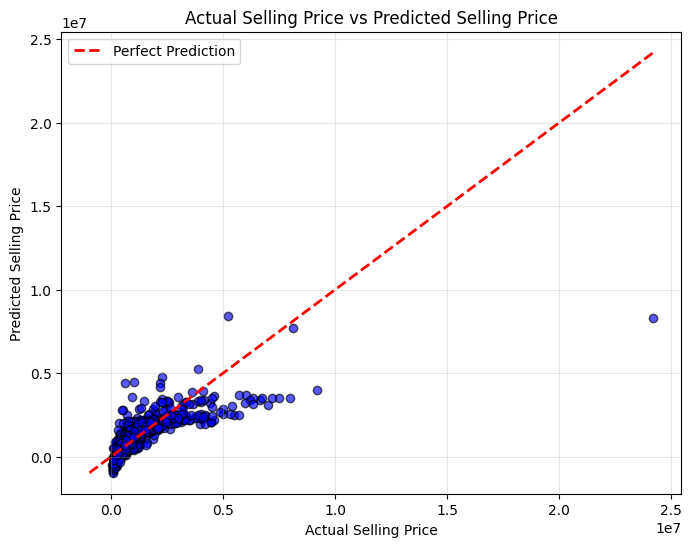

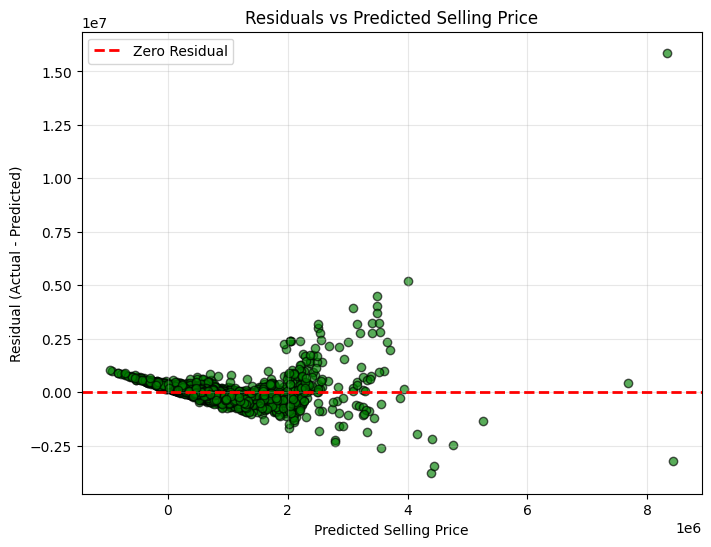

========== OBSERVATIONS WITH LARGEST ERRORS ==========


,Actual_Selling_Price,Predicted_Selling_Price,Residual,Absolute_Error
2796,24200000.0,8323205.42,15876794.58,15876794.58
2362,9200000.0,4009019.39,5190980.61,5190980.61
1382,8000000.0,3488916.56,4511083.44,4511083.44
841,7500000.0,3485713.74,4014286.26,4014286.26
246,7000000.0,3084722.09,3915277.91,3915277.91
26,625000.0,4390873.61,-3765873.61,3765873.61
1286,7199000.0,3488916.56,3710083.44,3710083.44
2528,999000.0,4439604.79,-3440604.79,3440604.79
2050,5200000.0,8434192.83,-3234192.83,3234192.83
1092,6645000.0,3412467.57,3232532.43,3232532.43



========== RESIDUAL STATISTICS ==========
Mean residual       : -10771.1920
Standard deviation  : 535701.7013
Mean absolute error : 266187.9613
Maximum absolute error: 15876794.5835

========== RESIDUAL ANALYSIS ==========
⚠ Residuals show some systematic bias away from zero.
Correlation between predicted values and residuals: -0.0373
✓ Residuals show relatively little linear pattern.

========== OBSERVATIONS ==========
1. In the Actual vs Predicted plot, observations closer to the red diagonal line represent more accurate predictions.
2. Points far from the diagonal line represent observations with larger prediction errors.
3. In the residual plot, residuals close to zero indicate small prediction errors.
4. Ideally, residuals should be randomly scattered around the zero line without a clear pattern.
5. Large residuals may occur because used-car prices can be affected by factors not included in the model, such as car condition, brand reputation, accident history, location, maintenanc

In [34]:
# ============================================================
# TASK 19: VISUALIZE AND ANALYZE MODEL PERFORMANCE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Calculate residuals
# ------------------------------------------------------------

residuals = ytest - y_pred

# Absolute prediction errors
absolute_errors = np.abs(residuals)

# ------------------------------------------------------------
# 2. Create Actual vs Predicted plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    ytest,
    y_pred,
    color="blue",
    alpha=0.65,
    edgecolors="black"
)

# Perfect prediction line: predicted = actual
min_value = min(ytest.min(), y_pred.min())
max_value = max(ytest.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="red",
    linewidth=2,
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual Selling Price vs Predicted Selling Price")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# ------------------------------------------------------------
# 3. Create residual plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    color="green",
    alpha=0.65,
    edgecolors="black"
)

# Zero-error reference line
plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Zero Residual"
)

plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted Selling Price")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# ------------------------------------------------------------
# 4. Identify observations with large prediction errors
# ------------------------------------------------------------

error_table = pd.DataFrame({
    "Actual_Selling_Price": ytest,
    "Predicted_Selling_Price": y_pred,
    "Residual": residuals,
    "Absolute_Error": absolute_errors
})

# Sort from largest to smallest error
largest_errors = error_table.sort_values(
    by="Absolute_Error",
    ascending=False
).head(10)

print("========== OBSERVATIONS WITH LARGEST ERRORS ==========")
display(largest_errors.round(2))

# ------------------------------------------------------------
# 5. Calculate residual statistics
# ------------------------------------------------------------

mean_residual = np.mean(residuals)
std_residual = np.std(residuals)

print("\n========== RESIDUAL STATISTICS ==========")
print(f"Mean residual       : {mean_residual:.4f}")
print(f"Standard deviation  : {std_residual:.4f}")
print(f"Mean absolute error : {np.mean(absolute_errors):.4f}")
print(f"Maximum absolute error: {np.max(absolute_errors):.4f}")

# ------------------------------------------------------------
# 6. Check whether residuals are approximately centered at zero
# ------------------------------------------------------------

print("\n========== RESIDUAL ANALYSIS ==========")

if abs(mean_residual) < 0.1:
    print("✓ Residuals are approximately centered around zero.")
else:
    print("⚠ Residuals show some systematic bias away from zero.")

# Check correlation between predictions and residuals
residual_correlation = np.corrcoef(
    y_pred,
    residuals
)[0, 1]

print(
    f"Correlation between predicted values and residuals: "
    f"{residual_correlation:.4f}"
)

if abs(residual_correlation) < 0.2:
    print("✓ Residuals show relatively little linear pattern.")
else:
    print("⚠ Residuals may contain a systematic pattern.")

# ------------------------------------------------------------
# 7. Record observations
# ------------------------------------------------------------

print("\n========== OBSERVATIONS ==========")

print(
    "1. In the Actual vs Predicted plot, observations closer to "
    "the red diagonal line represent more accurate predictions."
)

print(
    "2. Points far from the diagonal line represent observations "
    "with larger prediction errors."
)

print(
    "3. In the residual plot, residuals close to zero indicate "
    "small prediction errors."
)

print(
    "4. Ideally, residuals should be randomly scattered around "
    "the zero line without a clear pattern."
)

print(
    "5. Large residuals may occur because used-car prices can be "
    "affected by factors not included in the model, such as car "
    "condition, brand reputation, accident history, location, "
    "maintenance history, and demand."
)

print(
    "6. A non-random pattern or increasing spread of residuals "
    "could indicate that the linear model does not fully capture "
    "the relationship between the predictors and selling price."
)

print("\n✓ TASK 19 COMPLETED")

### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction


### Conclusion
Conclude the experiment by stating whether the Multiple Linear Regression model implemented using the OLS normal equation was able to predict used-car selling prices effectively. The conclusion should include the obtained RSS and R² values, observations regarding important features, the effect of preprocessing and feature engineering, and the limitations of using a linear regression model for real-world used-car price prediction.

## Resources